In [12]:
import scipy.io as sio
import numpy as np

class DreamerLoader:
    def __init__(self, mat_path="./DREAMER_RAW_DATASET/DREAMER.mat"):
        """
        Initializes the loader and caches the 500MB dataset into RAM once.
        """
        print(f"Loading DREAMER database into RAM from {mat_path}")
        self.raw_mat = sio.loadmat(mat_path)
        
        # Navigate the MATLAB struct to the core Data field
        self.data_field = self.raw_mat['DREAMER'][0, 0]['Data']
        self.num_subjects = self.data_field.shape[1]
        
        print(f"Database loaded successfully. {self.num_subjects} subjects available.")

    def get_subject_data(self, subject_id):
        """
        Extracts all 18 video trials and ground truth labels for a specific subject.
        subject_id: Integer from 1 to 23.
        Returns: A list of 18 dictionaries containing 'eeg_matrix', 'arousal', and 'valence'.
        """
        if subject_id < 1 or subject_id > self.num_subjects:
            raise ValueError(f"Subject ID must be between 1 and {self.num_subjects}")

        # Python is 0-indexed; Subject 1 is at index 0
        subject_idx = subject_id - 1
        
        # Isolate the specific subject's data tree
        subject_data = self.data_field[0, subject_idx]
        eeg_trials = subject_data['EEG'][0, 0]['stimuli'][0, 0]
        arousal_labels = subject_data['ScoreArousal'][0, 0]
        valence_labels = subject_data['ScoreValence'][0, 0]
        
        trials = []
        
        # Package all 18 videos into a clean Python list
        for trial_idx in range(18):
            trial_dict = {
                'eeg_matrix': eeg_trials[trial_idx, 0],  # Shape: (Samples, 14 Channels)
                'arousal': arousal_labels[trial_idx, 0],
                'valence': valence_labels[trial_idx, 0]
            }
            trials.append(trial_dict)
            
        return trials


In [ ]:
# PREPROCSSOR BUT WITH GRAPHS! don't use doesn't work properly with biological signals and feature pruning 

import numpy as np

class DreamerPreprocessor:
    def __init__(self, sfreq=128, window_sec=4.0, step_sec=2.0):
        self.sfreq = sfreq
        self.window_samples = int(sfreq * window_sec)
        self.step_samples = int(sfreq * step_sec)
        self.channel_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']

    def extract_graph_features(self, epoch_data):
        """
        Takes an epoch slice of shape (14, Samples).
        Computes a weighted adjacency matrix and extracts topological network features.
        """
        # 1. Compute 14x14 Pearson Correlation Matrix
        # np.corrcoef expects rows as variables (channels), columns as observations
        corr_matrix = np.corrcoef(epoch_data)
        
        # Handle any rare NaNs from flat signals
        corr_matrix = np.nan_to_num(corr_matrix)
        
        # 2. We want absolute connectivity strength (both hyper-sync and anti-sync matter)
        adj_matrix = np.abs(corr_matrix)
        
        # Zero out the self-connections (diagonal) so an electrode doesn't count as its own neighbor
        np.fill_diagonal(adj_matrix, 0)
        
        # 3. Feature 1: Node Strength (14 features - one per channel)
        node_strengths = np.sum(adj_matrix, axis=1)
        
        # 4. Feature 2: Global Network Density (1 feature - overall brain synchronization)
        global_density = np.mean(adj_matrix)
        
        # Combine into a flat vector of 15 highly dense spatial features
        graph_vector = np.append(node_strengths, global_density)
        
        return graph_vector

    def segment_into_epochs(self, raw_trial_data):
        total_samples = raw_trial_data.shape[0]
        num_channels = raw_trial_data.shape[1]

        # Common Average Reference (CAR) to clear global environment noise
        global_average = np.mean(raw_trial_data, axis=1, keepdims=True)
        car_trial_data = raw_trial_data - global_average

        num_epochs = (total_samples - self.window_samples) // self.step_samples + 1
        
        # We will return the cleaned raw epochs matrix
        epochs_matrix = np.zeros((num_epochs, num_channels, self.window_samples))
        graph_features_list = []

        for i in range(num_epochs):
            start_idx = i * self.step_samples
            end_idx = start_idx + self.window_samples
            
            epoch_slice = car_trial_data[start_idx:end_idx, :].T # Shape: (14, Samples)
            epochs_matrix[i] = epoch_slice
            
            # Extract the 15 graph metrics for this specific window
            graph_vector = self.extract_graph_features(epoch_slice)
            graph_features_list.append(graph_vector)

        # Stash the graph features as an attribute so your main pipeline loop can grab them!
        self.last_extracted_graph_features = np.array(graph_features_list) # Shape: (Num_Epochs, 15)

        return epochs_matrix

In [13]:
import numpy as np
from sklearn.decomposition import PCA

class DreamerPreprocessor:
    def __init__(self, sfreq=128, window_sec=4.0, step_sec=2.0):
        self.sfreq = sfreq
        self.window_samples = int(sfreq * window_sec)
        self.step_samples = int(sfreq * step_sec)
        self.channel_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']

    def apply_fast_artifact_rejection(self, raw_epoch_data):
        """
        The 'Poor Man's ICA'. 
        Takes a raw epoch (Samples x Channels), unmixes it via PCA, 
        kills the loudest component (usually an eye blink or jaw clench), 
        and reconstructs the clean EEG.
        """
        # 1. Initialize PCA to find the 14 spatial components
        pca = PCA(n_components=14)
        
        # 2. Unmix the signals (Samples x Components)
        components = pca.fit_transform(raw_epoch_data)
        
        # 3. ASSUMPTION: The component with the highest variance (Component 0) 
        # is almost always a physical artifact (blink/muscle) because the voltage is so high.
        # We delete it by multiplying that column by 0.
        components[:, 0] = 0.0 
        
        # 4. Inverse transform to rebuild the 14 channels without the artifact
        clean_epoch_data = pca.inverse_transform(components)
        
        return clean_epoch_data

    def segment_into_epochs(self, raw_trial_data):
        total_samples = raw_trial_data.shape[0]
        num_channels = raw_trial_data.shape[1]

        # RESTORED: Common Average Reference (CAR)
        global_average = np.mean(raw_trial_data, axis=1, keepdims=True)
        car_trial_data = raw_trial_data - global_average

        num_epochs = (total_samples - self.window_samples) // self.step_samples + 1
        epochs_matrix = np.zeros((num_epochs, num_channels, self.window_samples))

        for i in range(num_epochs):
            start_idx = i * self.step_samples
            end_idx = start_idx + self.window_samples
            
            # Slice the CAR data (no PCA!)
            epoch_slice = car_trial_data[start_idx:end_idx, :]
            epochs_matrix[i] = epoch_slice.T

        return epochs_matrix
    

    #execution

if __name__ == "__main__":
    import scipy.io as sio

    #loading DREAMER dataset
    mat_path = "./DREAMER_RAW_DATASET/DREAMER.mat"
    raw_mat = sio.loadmat(mat_path)
    subject_1 = raw_mat['DREAMER'][0,0]['Data'][0,0]

    trial_1_raw = subject_1['EEG'][0, 0]['stimuli'][0, 0][0, 0]

    preprocessor = DreamerPreprocessor(sfreq=128, window_sec=2.0, step_sec=1.0)

    epoched_data = preprocessor.segment_into_epochs(trial_1_raw)

    print(" Stage 1: Epoching complete")
    print(f"Original Trial Shape: {trial_1_raw.shape} (Samples, Channels)")
    print(f"Epoched Matrix Shape: {epoched_data.shape} (Epochs, Channels, Samples)")

 Stage 1: Epoching complete
Original Trial Shape: (25472, 14) (Samples, Channels)
Epoched Matrix Shape: (198, 14, 256) (Epochs, Channels, Samples)


In [15]:
import numpy as np
import scipy.signal as signal

class SpectralFeatureEngine:
    def __init__(self, sfreq=128):
        self.sfreq = sfreq
        # DREAMER Nyquist is 64Hz.
        
    def bandpass_filter(self, data, low, high):
        nyq = 0.5 * self.sfreq
        lowcut = low / nyq
        highcut = high / nyq
        b, a = signal.butter(4, [lowcut, highcut], btype='band')
        return signal.lfilter(b, a, data, axis=-1)

    def band_specific_zscore(self, data_band):
        mu = np.mean(data_band, axis=-1, keepdims=True)
        sigma = np.std(data_band, axis=-1, keepdims=True)
        sigma[sigma == 0] = 1e-6 
        return np.clip(data_band, mu - 3.0 * sigma, mu + 3.0 * sigma)

    def calculate_mti_epoch(self, epoch_matrix):
        """
        Calculates the raw Muscle Tension Index (high-frequency energy) 
        for all 14 channels in a single 2-second epoch.
        """
        mti_channels = np.zeros(epoch_matrix.shape[0])
        
        for ch_idx in range(epoch_matrix.shape[0]):
            channel_data = epoch_matrix[ch_idx]
            frequencies, times, Zxx = signal.stft(channel_data, fs=self.sfreq, nperseg=len(channel_data))
            spectral_power = np.abs(Zxx)**2
            
            # MTI is defined as energy > 50Hz (up to Nyquist 64Hz)
            noise_mask = (frequencies > 50)
            mti_channels[ch_idx] = np.sum(spectral_power[noise_mask])
            
        return mti_channels

    def process_all_epochs(self, epoched_data):
        """
        Processes the (Epochs, Channels, Samples) matrix.
        Returns Beta, Gamma, and the Relative \Delta MTI array.
        """
        num_epochs = epoched_data.shape[0]
        
        print(f"Processing {num_epochs} epochs into 3 distinct bands...")
        
        # 1. Isolate the Brainwave Bands
        beta_signal = self.bandpass_filter(epoched_data, 13.0, 30.0)
        gamma_signal = self.bandpass_filter(epoched_data, 30.0, 50.0)
        
        # 2. Apply Local Z-Score Normalization
        clean_beta = self.band_specific_zscore(beta_signal)
        clean_gamma = self.band_specific_zscore(gamma_signal)
        
        # 3. Calculate Raw MTI across all epochs: Shape -> (Epochs, 14 Channels)
        raw_mti_matrix = np.zeros((num_epochs, epoched_data.shape[1]))
        for i in range(num_epochs):
            raw_mti_matrix[i] = self.calculate_mti_epoch(epoched_data[i])
            
        # 4. Calculate \Delta MTI (Relative to this specific video trial)
        # We find the median tension per channel across the whole video as the "Baseline"
        baseline_mti = np.median(raw_mti_matrix, axis=0) 
        delta_mti_matrix = raw_mti_matrix - baseline_mti
        
        return clean_beta, clean_gamma, delta_mti_matrix

# Execution Test for Phase 2
if __name__ == "__main__":
    # Assuming 'epoched_data' (198, 14, 256) from Phase 1 is in memory
    
    engine = SpectralFeatureEngine(sfreq=128)
    
    beta_epochs, gamma_epochs, mti_features = engine.process_all_epochs(epoched_data)
    
    print("\nSpectral & EMG Separation Complete")
    print(f"Clean Beta Shape: {beta_epochs.shape} (Epochs, Channels, Samples)")
    print(f"Clean Gamma Shape: {gamma_epochs.shape} (Epochs, Channels, Samples)")
    print(f"Relative MTI Features Shape: {mti_features.shape} (Epochs, Channels)")

Processing 198 epochs into 3 distinct bands...

Spectral & EMG Separation Complete
Clean Beta Shape: (198, 14, 256) (Epochs, Channels, Samples)
Clean Gamma Shape: (198, 14, 256) (Epochs, Channels, Samples)
Relative MTI Features Shape: (198, 14) (Epochs, Channels)


In [16]:
import numpy as np
import librosa
import math

class FeatureExtractionEngine:
    def __init__(self, sfreq=128):
        self.sfreq = sfreq
        
        # 14 Channels of DREAMER
        self.ch_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
        
        # 7 Symmetrical Pairs (Left Index, Right Index)
        self.pairs = [
            (0, 13),  # AF3 - AF4
            (1, 12),  # F7  - F8
            (2, 11),  # F3  - F4
            (3, 10),  # FC5 - FC6
            (4, 9),   # T7  - T8
            (5, 8),   # P7  - P8
            (6, 7)    # O1  - O2
        ]

    def calc_differential_entropy(self, signal_1d):
        """Calculates DE for a 1D brainwave array."""
        variance = np.var(signal_1d)
        # Add epsilon 1e-8 to prevent log(0)
        de = 0.5 * np.log(2 * np.pi * math.e * variance + 1e-8)
        return de

    def extract_band_features(self, epoch_band_matrix):
        """
        Takes a single epoch for a single band (14, 256).
        Returns a flat array of DE, DASM, RASM, and Librosa textures (including MFCCs).
        """
        de_vals = np.zeros(14)
        rms_vals = np.zeros(14)
        zcr_vals = np.zeros(14)
        centroid_vals = np.zeros(14)
        
        # We will extract 4 MFCCs per channel. Shape: (14 channels, 4 coefficients)
        n_mfcc = 4
        mfcc_vals = np.zeros((14, n_mfcc)) 
        
        # 1. Base Features per Channel
        for ch in range(14):
            sig = epoch_band_matrix[ch]
            
            # Differential Entropy
            de_vals[ch] = self.calc_differential_entropy(sig)
            
            # Librosa Acoustic Textures
            # Use frame_length=256 and hop_length=64 (which gives us 4 frames per epoch to average)
            rms_vals[ch] = librosa.feature.rms(y=sig, frame_length=256, hop_length=64)[0][0]
            zcr_vals[ch] = librosa.feature.zero_crossing_rate(y=sig, frame_length=256, hop_length=64)[0][0]

            # Use n_fft=256 for the spectral functions
            centroid_vals[ch] = librosa.feature.spectral_centroid(y=sig, sr=self.sfreq, n_fft=256, hop_length=64)[0][0]
            raw_mfccs = librosa.feature.mfcc(y=sig, sr=self.sfreq, n_mfcc=n_mfcc, n_fft=256, hop_length=64)
            mfcc_vals[ch] = np.mean(raw_mfccs, axis=1)
            
        # 2. Spatial Asymmetry (DASM, RASM, Acoustic Asymmetry)
        dasm_vals = np.zeros(7)
        rasm_vals = np.zeros(7)
        rms_diff_vals = np.zeros(7)
        
        for i, (left_idx, right_idx) in enumerate(self.pairs):
            de_l = de_vals[left_idx]
            de_r = de_vals[right_idx]
            
            dasm_vals[i] = de_l - de_r
            rasm_vals[i] = de_l / (de_r + 1e-8) 
            rms_diff_vals[i] = rms_vals[left_idx] - rms_vals[right_idx]
            
        # Flatten the (14, 4) MFCC matrix into a 1D array of 56 values
        flat_mfccs = mfcc_vals.flatten()
            
        # 3. Concatenate everything into a single 1D vector
        epoch_features = np.concatenate([
            de_vals, dasm_vals, rasm_vals, 
            rms_vals, zcr_vals, centroid_vals, rms_diff_vals,
            flat_mfccs  
        ])
        
        return epoch_features

    def process_all_epochs(self, beta_epochs, gamma_epochs, mti_features):
        """
        Processes all epochs into the final XGBoost training matrix.
        """
        num_epochs = beta_epochs.shape[0]
        final_feature_matrix = []
        
        print(f"Extracting Acoustic and DE features for {num_epochs} epochs...")
        
        for i in range(num_epochs):
            # Extract features for Beta and Gamma independently
            beta_feats = self.extract_band_features(beta_epochs[i])
            gamma_feats = self.extract_band_features(gamma_epochs[i])
            
            # Grab the 14 \Delta MTI features we generated in Phase 2
            mti_feats = mti_features[i]
            
            # Fuse everything for this epoch
            fused_vector = np.concatenate([beta_feats, gamma_feats, mti_feats])
            final_feature_matrix.append(fused_vector)
            
        return np.array(final_feature_matrix)

# --- Execution Test for Phase 3 ---
if __name__ == "__main__":
    # Assuming beta_epochs, gamma_epochs, and mti_features are in memory
    
    extractor = FeatureExtractionEngine(sfreq=128)
    
    # Generate the ultimate feature matrix
    X_matrix = extractor.process_all_epochs(beta_epochs, gamma_epochs, mti_features)
    
    print("\nFeature Extraction Complete")
    print(f"Final Input Matrix (X) Shape: {X_matrix.shape} (Epochs, Features)")
    
    # Let's see exactly how many features we engineered per 2.0s window
    num_features = X_matrix.shape[1]
    print(f"Total engineered features per epoch: {num_features}")

Extracting Acoustic and DE features for 198 epochs...

Feature Extraction Complete
Final Input Matrix (X) Shape: (198, 280) (Epochs, Features)
Total engineered features per epoch: 280


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

def get_feature_names():
    """Generates the exact strings for our 280 engineered features."""
    ch_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
    pairs = ['AF3-AF4', 'F7-F8', 'F3-F4', 'FC5-FC6', 'T7-T8', 'P7-P8', 'O1-O2']
    
    bands = ['Beta', 'Gamma']
    feature_names = []
    
    for band in bands:
        # Base Features (14 each)
        for ch in ch_names: feature_names.append(f"{band}_DE_{ch}")
        
        # Spatial Asymmetry (7 each)
        for p in pairs: feature_names.append(f"{band}_DASM_{p}")
        for p in pairs: feature_names.append(f"{band}_RASM_{p}")
        
        # Librosa Textures (14 each)
        for ch in ch_names: feature_names.append(f"{band}_RMS_{ch}")
        for ch in ch_names: feature_names.append(f"{band}_ZCR_{ch}")
        for ch in ch_names: feature_names.append(f"{band}_Centroid_{ch}")
        
        # Acoustic Asymmetry (7)
        for p in pairs: feature_names.append(f"{band}_Acoustic_Asym_{p}")
            
        # MFCCs (14 channels * 4 coefficients = 56)
        for ch in ch_names:
            for m in range(1, 5):
                feature_names.append(f"{band}_MFCC{m}_{ch}")
                
    # \Delta MTI Features (14)
    for ch in ch_names: feature_names.append(f"Delta_MTI_{ch}")
        
    return feature_names

def plot_top_features(model, top_n=25):
    """Maps XGBoost weights to our named features and plots them."""
    names = get_feature_names()
    
    # Extract feature importances (Gain is usually best for biological relevance)
    importances = model.feature_importances_
    
    # Sort and grab top N
    indices = np.argsort(importances)[-top_n:]
    top_names = [names[i] for i in indices]
    top_scores = importances[indices]
    
    plt.figure(figsize=(10, 8))
    plt.barh(top_names, top_scores, color='teal')
    plt.xlabel("XGBoost Feature Importance (Gain)")
    plt.title(f"Top {top_n} Acoustic-Affective Drivers for Subject 1")
    plt.tight_layout()
    plt.show()



# To run this, just pass your trained model from Phase 4:
# plot_top_features(model)

Initiating Phase 4: Full Pipeline Integration for Subject 1
Loading DREAMER database into RAM from ./DREAMER_RAW_DATASET/DREAMER.mat
Database loaded successfully. 23 subjects available.

Processing Video Trial 1/18...
Processing 198 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 198 epochs...

Processing Video Trial 2/18...
Processing 130 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 130 epochs...

Processing Video Trial 3/18...
Processing 347 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 347 epochs...

Processing Video Trial 4/18...
Processing 165 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 165 epochs...

Processing Video Trial 5/18...
Processing 135 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 135 epochs...

Processing Video Trial 6/18...
Processing 189 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 189 epochs...

Processing Vide

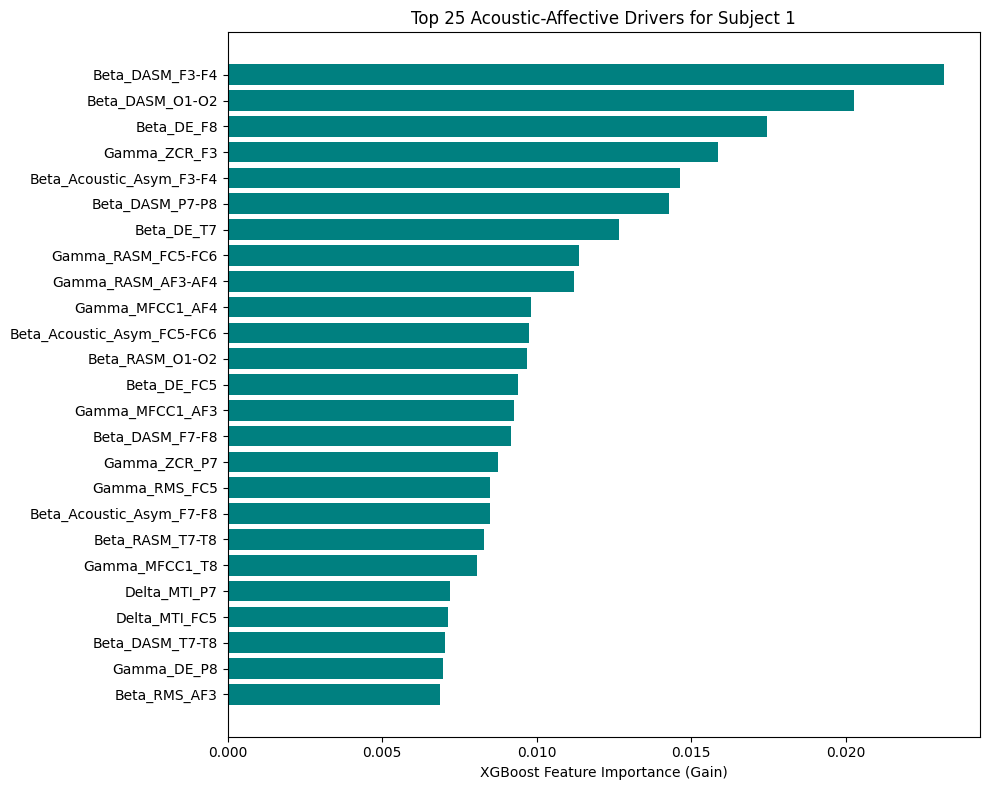

In [16]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


def train_subject_model(subject_id=1):
    print(f"Initiating Phase 4: Full Pipeline Integration for Subject {subject_id}")
    
    # 1. Initialize our Engines
    loader = DreamerLoader(mat_path="./DREAMER_RAW_DATASET/DREAMER.mat")
    preprocessor = DreamerPreprocessor(sfreq=128, window_sec=2.0, step_sec=1.0)
    spectral_engine = SpectralFeatureEngine(sfreq=128)
    feature_engine = FeatureExtractionEngine(sfreq=128)
    
    # 2. Fetch all 18 trials using your clean Phase 1 class
    trials = loader.get_subject_data(subject_id=subject_id)
    
    X_all = []
    y_arousal = []
    
    # 3. Process every video
    for idx, trial in enumerate(trials):
        print(f"\nProcessing Video Trial {idx + 1}/18...")
        
        # FIXED: Using the correct dictionary keys from Phase 1
        # The array is already shaped (Samples, 14), so no transpose (.T) is needed!
        raw_trial_matrix = trial['eeg_matrix'] 
        arousal_score = trial['arousal']
        
        # Binarize Label (1 if > 3, 0 if <= 3)
        binary_label = 1 if arousal_score > 3 else 0
        
        # Run the Pipeline
        epoched = preprocessor.segment_into_epochs(raw_trial_matrix)
        beta, gamma, mti = spectral_engine.process_all_epochs(epoched)
        X_matrix = feature_engine.process_all_epochs(beta, gamma, mti)
        
        # Append to our master list
        X_all.append(X_matrix)
        
        # Assign the same label to every 2-second epoch in this video
        num_epochs_in_trial = X_matrix.shape[0]
        y_arousal.extend([binary_label] * num_epochs_in_trial)
        
    # 4. Stack everything into massive 2D arrays
    X_final = np.vstack(X_all)
    y_final = np.array(y_arousal)
    
    print(f"\nData Aggregation Complete")
    print(f"Total Dataset Shape: X={X_final.shape}, Y={y_final.shape}")
    
    # 5. Train / Test Split (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
    )
    
    # 6. Initialize and Train the XGBoost "Leader"
    print("\nTraining XGBoost Leader Model")
    model = xgb.XGBClassifier(
        n_estimators=100, 
        max_depth=6, 
        learning_rate=0.1, 
        objective='binary:logistic',
        eval_metric='logloss'
    )
    
    model.fit(X_train, y_train)
    
    # 7. Evaluate
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    print("\nFinal Classification Report (Arousal)")
    print(classification_report(y_test, preds, target_names=["Low Arousal", "High Arousal"]))
    print(f"Baseline Accuracy on Subject {subject_id}: {acc * 100:.2f}%")
    plot_top_features(model)

if __name__ == "__main__":
    train_subject_model(subject_id=1)

In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

def run_monte_carlo_grid_search(X, y, iterations=100):
    print("\nStep 1: Initiating Grid Search for Hyperparameter Tuning")
    
    # Base model
    xgb_base = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')
    
    # The Grid (Tuned for our acoustic-affective matrix)
    param_grid = {
        'max_depth': [4, 6],
        'learning_rate': [0.05, 0.1],
        'n_estimators': [50, 100]
    }
    
    # n_jobs=-1 tells sklearn to use EVERY core on your CPU
    grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X, y)
    
    best_params = grid_search.best_params_
    print(f"Optimal Architecture Found: {best_params}")
    
    print(f"\nStep 2: Initiating {iterations}-Iteration Monte Carlo Validation")
    optimal_model = xgb.XGBClassifier(**best_params, objective='binary:logistic', eval_metric='logloss')
    
    # Stratified split ensures the 2:1 Low/High arousal ratio is respected in every single shuffle
    sss = StratifiedShuffleSplit(n_splits=iterations, test_size=0.2, random_state=None)
    
    accuracies = []
    
    for i, (train_index, test_index) in enumerate(sss.split(X, y)):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        optimal_model.fit(X_train, y_train)
        preds = optimal_model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        
        if (i + 1) % 10 == 0:
            print(f"  -> Completed iteration {i + 1}/{iterations} (Current Rolling Avg: {np.mean(accuracies)*100:.2f}%)")
            
    final_mean_acc = np.mean(accuracies) * 100
    final_std_dev = np.std(accuracies) * 100
    
    print("\nFinal Monte Carlo Validation Results")
    print(f"Robust Accuracy: {final_mean_acc:.2f}% (±{final_std_dev:.2f}%)")
    
    return optimal_model

def execute_subject_benchmark(subject_id=1):
    print(f"Initiating Full Pipeline Benchmark for Subject {subject_id}")
    
    loader = DreamerLoader(mat_path="./DREAMER_RAW_DATASET/DREAMER.mat")
    preprocessor = DreamerPreprocessor(sfreq=128, window_sec=2.0, step_sec=1.0)
    spectral_engine = SpectralFeatureEngine(sfreq=128)
    feature_engine = FeatureExtractionEngine(sfreq=128)
    
    trials = loader.get_subject_data(subject_id=subject_id)
    
    X_all = []
    y_arousal = []
    
    print("\nExtracting Acoustic-Affective Features")
    for trial in trials:
        raw_trial_matrix = trial['eeg_matrix'] 
        arousal_score = trial['arousal']
        
        binary_label = 1 if arousal_score > 3 else 0
        
        epoched = preprocessor.segment_into_epochs(raw_trial_matrix)
        beta, gamma, mti = spectral_engine.process_all_epochs(epoched)
        X_matrix = feature_engine.process_all_epochs(beta, gamma, mti)
        
        X_all.append(X_matrix)
        y_arousal.extend([binary_label] * X_matrix.shape[0])
        
    X_final = np.vstack(X_all)
    y_final = np.array(y_arousal)

    print("Scaling features to zero-mean, unit-variance")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_final)
    
    print(f"Data Aggregated: X={X_final.shape}, Y={y_final.shape}")
    
    # Run the Monte Carlo Grid Search
    final_model = run_monte_carlo_grid_search(X_final, y_final, iterations=100)

if __name__ == "__main__":
    execute_subject_benchmark(subject_id=1)

Initiating Full Pipeline Benchmark for Subject 1
Loading DREAMER database into RAM from ./DREAMER_RAW_DATASET/DREAMER.mat
Database loaded successfully. 23 subjects available.

Extracting Acoustic-Affective Features
Processing 198 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 198 epochs...
Processing 130 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 130 epochs...
Processing 347 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 347 epochs...
Processing 165 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 165 epochs...
Processing 135 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 135 epochs...
Processing 189 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 189 epochs...
Processing 191 epochs into 3 distinct bands...
Extracting Acoustic and DE features for 191 epochs...
Processing 393 epochs into 3 distinct bands...
Extracting Acoustic and DE feat

In [ ]:
#XGBOOST THE GOD! gave the highest at 66 percent accuracy

import os
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, classification_report

# Create a folder to save our extracted matrices
# Change this:
SAVE_DIR = "./DREAMER_FEATURES_EXTREME_CLASSES"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

def extract_and_save_all_subjects(total_subjects=23):
    """Runs the 5-minute pipeline on every subject and saves the arrays to disk."""
    loader = DreamerLoader(mat_path="./DREAMER_RAW_DATASET/DREAMER.mat")
    preprocessor = DreamerPreprocessor(sfreq=128, window_sec=4.0, step_sec=2.0)
    spectral_engine = SpectralFeatureEngine(sfreq=128)
    feature_engine = FeatureExtractionEngine(sfreq=128)
    
    for sub_id in range(1, total_subjects + 1):
        save_path_X = os.path.join(SAVE_DIR, f"Sub_{sub_id}_X.npy")
        save_path_y = os.path.join(SAVE_DIR, f"Sub_{sub_id}_y.npy")
        
        # Skip if we already processed this person
        if os.path.exists(save_path_X) and os.path.exists(save_path_y):
            print(f"Subject {sub_id} already extracted. Skipping.")
            continue
            
        print(f"\nExtracting Acoustic-Affective Features for Subject {sub_id}")
        try:
            trials = loader.get_subject_data(subject_id=sub_id)
            X_all, y_arousal = [], []
            
            # --- FIX 1: Properly indented inside the try block ---
            for trial in trials:
                # Double check that 'eeg_matrix' matches the key from your loader dictionary!
                raw_trial_matrix = trial['eeg_matrix'] 
                arousal_score = trial['arousal']
                
                # --- NEW EXTREME CLASS LOGIC ---
                if arousal_score == 3:
                    # Optional: print to track how many neutral trials are dropped
                    # print("  -> Dropping Neutral Trial") 
                    continue 
                    
                binary_label = 1 if arousal_score > 3 else 0
                
                epoched = preprocessor.segment_into_epochs(raw_trial_matrix)
                beta, gamma, mti = spectral_engine.process_all_epochs(epoched)
                X_matrix = feature_engine.process_all_epochs(beta, gamma, mti)
                    
                X_all.append(X_matrix)
                y_arousal.extend([binary_label] * X_matrix.shape[0])
            
            # --- FIX 3: Safety net for empty arrays ---
            if len(X_all) == 0:
                print(f"Subject {sub_id} had exclusively neutral (3) ratings. No extreme data to save.")
                continue

            # --- FIX 2: Safely outside the trial loop, but inside the try block ---
            X_final = np.vstack(X_all)
            y_final = np.array(y_arousal)
            
            # Save to disk
            np.save(save_path_X, X_final)
            np.save(save_path_y, y_final)
            print(f"Subject {sub_id} Saved: X={X_final.shape}, Y={y_final.shape}")
            
        except Exception as e:
            print(f"Error on Subject {sub_id}: {e}")

from sklearn.preprocessing import StandardScaler
import numpy as np

def apply_subject_wise_scaling(X_global, subjects_global):
    """
    Applies Z-score normalization independently to each subject to 
    eliminate physiological baseline drift before cross-validation.
    
    Parameters:
    X_global: 2D numpy array of all extracted features (Total Epochs x Features)
    subjects_global: 1D numpy array mapping each epoch to a Subject ID (e.g., [1, 1, 2, 2...])
    
    Returns:
    X_scaled: 2D numpy array normalized per subject.
    """
    # Create an empty array of the exact same shape to hold our scaled features
    X_scaled = np.zeros_like(X_global, dtype=float)
    
    # Get the unique subject IDs (e.g., 1 through 23 for DREAMER)
    unique_subjects = np.unique(subjects_global)
    
    print(f"Applying Subject-Wise Scaling across {len(unique_subjects)} subjects...")
    
    for subj in unique_subjects:
        # Create a boolean mask to isolate only this subject's epochs
        subj_mask = (subjects_global == subj)
        
        # Initialize a fresh scaler for this specific user
        scaler = RobustScaler()
        
        # Fit to THEIR baseline and transform THEIR data
        X_scaled[subj_mask] = scaler.fit_transform(X_global[subj_mask])
        
    print("Scaling complete. Physiological baselines neutralized.")
    return X_scaled


def run_loso_validation(total_subjects=23):
    """Loads the saved files, scales per subject, and runs LOSO."""
    print("\nInitiating Leave-One-Subject-Out (LOSO) Validation")
    
    # Load all data into memory AND apply Subject-Wise Scaling immediately
    subject_data = {}
    for sub_id in range(1, total_subjects + 1):
        try:
            X_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_X.npy"))
            y = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_y.npy"))
            
            #Scale this specific subject's data against their OWN biological baseline
            scaler = RobustScaler()
            X_scaled = scaler.fit_transform(X_raw) 
            
            subject_data[sub_id] = {'X': X_scaled, 'y': y}
            
        except FileNotFoundError:
            print(f"Missing data for Subject {sub_id}")
            return
            
    loso_accuracies = []
    
    # The LOSO Loop
    for test_sub_id in range(1, total_subjects + 1):
        print(f"\nTesting on Subject {test_sub_id}")
        
        # 1. Separate Test Data (It is already subject-scaled!)
        X_test = subject_data[test_sub_id]['X']
        y_test = subject_data[test_sub_id]['y']
        
        # 2. Gather Training Data (Everyone EXCEPT test_sub_id)
        X_train_list = [subject_data[i]['X'] for i in range(1, total_subjects + 1) if i != test_sub_id]
        y_train_list = [subject_data[i]['y'] for i in range(1, total_subjects + 1) if i != test_sub_id]
        
        X_train = np.vstack(X_train_list)
        y_train = np.concatenate(y_train_list)
        
        # 3. Train the Model (No global scaling needed here anymore!)
        model = xgb.XGBClassifier(
            learning_rate=0.05, 
            max_depth=4, 
            n_estimators=50, 
            objective='binary:logistic',
            eval_metric='logloss',
            random_state = 42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        
        # 4. Evaluate
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        loso_accuracies.append(acc)
        print(f"Subject {test_sub_id} Accuracy: {acc * 100:.2f}%")
        
    # Final Verdict
    print("\nFINAL LOSO BENCHMARK")
    print(f"Global Cross-Subject Accuracy: {np.mean(loso_accuracies)*100:.2f}% (±{np.std(loso_accuracies)*100:.2f}%)")

if __name__ == "__main__":
    # Step 1: Run this FIRST. Grab a coffee. It will take ~2 hours.
    # If it crashes or you stop it, running it again will pick up exactly where it left off!
    extract_and_save_all_subjects(total_subjects=23)    
    # Step 2: Once extraction is done, run the Machine Learning loop
    run_loso_validation(total_subjects=23)

Loading DREAMER database into RAM from ./DREAMER_RAW_DATASET/DREAMER.mat
Database loaded successfully. 23 subjects available.
Subject 1 already extracted. Skipping.
Subject 2 already extracted. Skipping.
Subject 3 already extracted. Skipping.
Subject 4 already extracted. Skipping.
Subject 5 already extracted. Skipping.
Subject 6 already extracted. Skipping.
Subject 7 already extracted. Skipping.
Subject 8 already extracted. Skipping.
Subject 9 already extracted. Skipping.
Subject 10 already extracted. Skipping.
Subject 11 already extracted. Skipping.
Subject 12 already extracted. Skipping.
Subject 13 already extracted. Skipping.
Subject 14 already extracted. Skipping.
Subject 15 already extracted. Skipping.
Subject 16 already extracted. Skipping.
Subject 17 already extracted. Skipping.
Subject 18 already extracted. Skipping.
Subject 19 already extracted. Skipping.
Subject 20 already extracted. Skipping.
Subject 21 already extracted. Skipping.
Subject 22 already extracted. Skipping.
Sub

In [ ]:
import os
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC

# Create a folder to save our extracted matrices
# Change this:
SAVE_DIR = "./DREAMER_FEATURES_EXTREME_CLASSES"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

def extract_and_save_all_subjects(total_subjects=23):
    """Runs the 5-minute pipeline on every subject and saves the arrays to disk."""
    loader = DreamerLoader(mat_path="./DREAMER_RAW_DATASET/DREAMER.mat")
    preprocessor = DreamerPreprocessor(sfreq=128, window_sec=4.0, step_sec=2.0)
    spectral_engine = SpectralFeatureEngine(sfreq=128)
    feature_engine = FeatureExtractionEngine(sfreq=128)
    
    for sub_id in range(1, total_subjects + 1):
        save_path_X = os.path.join(SAVE_DIR, f"Sub_{sub_id}_X.npy")
        save_path_y = os.path.join(SAVE_DIR, f"Sub_{sub_id}_y.npy")
        
        # Skip if we already processed this person
        if os.path.exists(save_path_X) and os.path.exists(save_path_y):
            print(f"Subject {sub_id} already extracted. Skipping.")
            continue
            
        print(f"\nExtracting Acoustic-Affective Features for Subject {sub_id}")
        try:
            trials = loader.get_subject_data(subject_id=sub_id)
            X_all, y_arousal = [], []
            
            # --- FIX 1: Properly indented inside the try block ---
            for trial in trials:
                # Double check that 'eeg_matrix' matches the key from your loader dictionary!
                raw_trial_matrix = trial['eeg_matrix'] 
                arousal_score = trial['arousal']
                
                # --- NEW EXTREME CLASS LOGIC ---
                if arousal_score == 3:
                    # Optional: print to track how many neutral trials are dropped
                    # print("  -> Dropping Neutral Trial") 
                    continue 
                    
                binary_label = 1 if arousal_score > 3 else 0
                
                epoched = preprocessor.segment_into_epochs(raw_trial_matrix)
                beta, gamma, mti = spectral_engine.process_all_epochs(epoched)
                X_matrix = feature_engine.process_all_epochs(beta, gamma, mti)
                    
                X_all.append(X_matrix)
                y_arousal.extend([binary_label] * X_matrix.shape[0])
            
            # --- FIX 3: Safety net for empty arrays ---
            if len(X_all) == 0:
                print(f"Subject {sub_id} had exclusively neutral (3) ratings. No extreme data to save.")
                continue

            # --- FIX 2: Safely outside the trial loop, but inside the try block ---
            X_final = np.vstack(X_all)
            y_final = np.array(y_arousal)
            
            # Save to disk
            np.save(save_path_X, X_final)
            np.save(save_path_y, y_final)
            print(f"Subject {sub_id} Saved: X={X_final.shape}, Y={y_final.shape}")
            
        except Exception as e:
            print(f"Error on Subject {sub_id}: {e}")

from sklearn.preprocessing import StandardScaler
import numpy as np

def apply_subject_wise_scaling(X_global, subjects_global):
    """
    Applies Z-score normalization independently to each subject to 
    eliminate physiological baseline drift before cross-validation.
    
    Parameters:
    X_global: 2D numpy array of all extracted features (Total Epochs x Features)
    subjects_global: 1D numpy array mapping each epoch to a Subject ID (e.g., [1, 1, 2, 2...])
    
    Returns:
    X_scaled: 2D numpy array normalized per subject.
    """
    # Create an empty array of the exact same shape to hold our scaled features
    X_scaled = np.zeros_like(X_global, dtype=float)
    
    # Get the unique subject IDs (e.g., 1 through 23 for DREAMER)
    unique_subjects = np.unique(subjects_global)
    
    print(f"Applying Subject-Wise Scaling across {len(unique_subjects)} subjects...")
    
    for subj in unique_subjects:
        # Create a boolean mask to isolate only this subject's epochs
        subj_mask = (subjects_global == subj)
        
        # Initialize a fresh scaler for this specific user
        scaler = RobustScaler()
        
        # Fit to THEIR baseline and transform THEIR data
        X_scaled[subj_mask] = scaler.fit_transform(X_global[subj_mask])
        
    print("Scaling complete. Physiological baselines neutralized.")
    return X_scaled

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

def run_loso_validation(total_subjects=23):
    """Loads the saved files, scales per subject, and runs LOSO."""
    print("\nInitiating Leave-One-Subject-Out (LOSO) Validation")
    
    # Load all data into memory AND apply Subject-Wise Scaling immediately
    subject_data = {}
    for sub_id in range(1, total_subjects + 1):
        try:
            X_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_X.npy"))
            y = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_y.npy"))
            
            #Scale this specific subject's data against their OWN biological baseline
            scaler = RobustScaler()
            X_scaled = scaler.fit_transform(X_raw) 
            
            subject_data[sub_id] = {'X': X_scaled, 'y': y}
            
        except FileNotFoundError:
            print(f"Missing data for Subject {sub_id}")
            return
            
    loso_accuracies = []
    
    # The LOSO Loop
    for test_sub_id in range(1, total_subjects + 1):
        print(f"\nTesting on Subject {test_sub_id}")
        
        # 1. Separate Test Data (It is already subject-scaled!)
        X_test = subject_data[test_sub_id]['X']
        y_test = subject_data[test_sub_id]['y']
        
        # 2. Gather Training Data (Everyone EXCEPT test_sub_id)
        X_train_list = [subject_data[i]['X'] for i in range(1, total_subjects + 1) if i != test_sub_id]
        y_train_list = [subject_data[i]['y'] for i in range(1, total_subjects + 1) if i != test_sub_id]
        
        X_train = np.vstack(X_train_list)
        y_train = np.concatenate(y_train_list)

        # PRUNING: Force the model to only look at the 20 most powerful features
        selector = SelectKBest(score_func=f_classif, k=20)
        
        # Fit the selector ONLY on training data to prevent leakage
        X_train_pruned = selector.fit_transform(X_train, y_train)
        X_test_pruned = selector.transform(X_test)
        
        # 3. Train the Model (No global scaling needed here anymore!)
        model = SVC(
            kernel='rbf', 
            C=1.0, 
            gamma='scale', 
            class_weight='balanced', 
            random_state=6
        )
        model.fit(X_train_pruned, y_train)
        
        # 4. Evaluate
        preds = model.predict(X_test_pruned)
        acc = accuracy_score(y_test, preds)
        loso_accuracies.append(acc)
        print(f"Subject {test_sub_id} Accuracy: {acc * 100:.2f}%")
        
    # Final Verdict
    print("\nFINAL LOSO BENCHMARK")
    print(f"Global Cross-Subject Accuracy: {np.mean(loso_accuracies)*100:.2f}% (±{np.std(loso_accuracies)*100:.2f}%)")

if __name__ == "__main__":
    # Step 1: Run this FIRST. Grab a coffee. It will take ~2 hours.
    # If it crashes or you stop it, running it again will pick up exactly where it left off!
    extract_and_save_all_subjects(total_subjects=23)    
    # Step 2: Once extraction is done, run the Machine Learning loop
    run_loso_validation(total_subjects=23)

In [19]:
import os
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score

SAVE_DIR = "./DREAMER_FEATURES_EXTREME_CLASSES"

def run_full_intra_subject_benchmark(total_subjects=23):
    print("\n=== Initiating Full Intra-Subject (Personalized) Benchmark ===")
    
    subject_accuracies = []
    
    # We use the exact same XGBoost architecture for a fair comparison
    base_model = xgb.XGBClassifier(
        learning_rate=0.05, 
        max_depth=4, 
        n_estimators=50, 
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    
    for sub_id in range(1, total_subjects + 1):
        try:
            # 1. Load ONLY this subject's data
            X_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_X.npy"))
            y = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_y.npy"))
            
            # 2. Scale the data to their own biological baseline
            scaler = RobustScaler()
            X_scaled = scaler.fit_transform(X_raw)
            
            # 3. Setup 5-Fold Cross Validation just for them
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            fold_accs = []
            
            for train_idx, test_idx in skf.split(X_scaled, y):
                X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]
                
                # Train and predict
                base_model.fit(X_train, y_train)
                preds = base_model.predict(X_test)
                fold_accs.append(accuracy_score(y_test, preds))
                
            # Average the folds for this specific person
            sub_mean_acc = np.mean(fold_accs) * 100
            subject_accuracies.append(sub_mean_acc)
            
            print(f"Subject {sub_id} Personalized Accuracy: {sub_mean_acc:.2f}%")
            
        except FileNotFoundError:
            print(f"Skipping Subject {sub_id} - Data not found.")
            
    # Calculate the global average of how well the personalized models did
    global_intra_acc = np.mean(subject_accuracies)
    global_intra_std = np.std(subject_accuracies)
    
    print("FINAL INTRA-SUBJECT BENCHMARK (The 'Perfect Fingerprint' Ceiling)")
    print(f"Global Average Accuracy: {global_intra_acc:.2f}% (±{global_intra_std:.2f}%)")

if __name__ == "__main__":
    # You already ran extraction, so just run this!
    run_full_intra_subject_benchmark(total_subjects=23)


=== Initiating Full Intra-Subject (Personalized) Benchmark ===
Subject 1 Personalized Accuracy: 86.49%
Subject 2 Personalized Accuracy: 90.28%
Subject 3 Personalized Accuracy: 81.74%
Subject 4 Personalized Accuracy: 99.92%
Subject 5 Personalized Accuracy: 93.72%
Subject 6 Personalized Accuracy: 99.17%
Subject 7 Personalized Accuracy: 96.08%
Subject 8 Personalized Accuracy: 76.58%
Subject 9 Personalized Accuracy: 96.36%
Subject 10 Personalized Accuracy: 77.81%
Subject 11 Personalized Accuracy: 87.49%
Subject 12 Personalized Accuracy: 91.55%
Subject 13 Personalized Accuracy: 99.62%
Subject 14 Personalized Accuracy: 92.95%
Subject 15 Personalized Accuracy: 95.19%
Subject 16 Personalized Accuracy: 91.39%
Subject 17 Personalized Accuracy: 87.55%
Subject 18 Personalized Accuracy: 97.87%
Subject 19 Personalized Accuracy: 97.93%
Subject 20 Personalized Accuracy: 97.48%
Subject 21 Personalized Accuracy: 88.08%
Subject 22 Personalized Accuracy: 96.18%
Subject 23 Personalized Accuracy: 96.12%
FI

In [21]:
import os
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score

SAVE_DIR = "./DREAMER_FEATURES_EXTREME_CLASSES"

def run_true_intra_subject_benchmark(total_subjects=23):
    print("\n=== Initiating TRUE Intra-Subject Benchmark (No Leakage) ===")
    
    subject_accuracies = []
    
    base_model = xgb.XGBClassifier(
        learning_rate=0.05, 
        max_depth=4, 
        n_estimators=50, 
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    
    for sub_id in range(1, total_subjects + 1):
        try:
            # 1. Load Data (It is already naturally in chronological order)
            X_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_X.npy"))
            y = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_y.npy"))
            
            # 2. Scale 
            scaler = RobustScaler()
            X_scaled = scaler.fit_transform(X_raw)
            
            # 3. Chronological Block Split (80% Train, 20% Test)
            # No shuffling! Respect the timeline.
            split_index = int(len(X_scaled) * 0.80)
            
            X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
            y_train, y_test = y[:split_index], y[split_index:]
            
            # 4. Train and predict
            base_model.fit(X_train, y_train)
            preds = base_model.predict(X_test)
            acc = accuracy_score(y_test, preds) * 100
            
            subject_accuracies.append(acc)
            print(f"Subject {sub_id} True Personalized Accuracy: {acc:.2f}%")
            
        except FileNotFoundError:
            print(f"Skipping Subject {sub_id} - Data not found.")
            
    # Global average
    global_intra_acc = np.mean(subject_accuracies)
    global_intra_std = np.std(subject_accuracies)
    
    print("FINAL TRUE INTRA-SUBJECT BENCHMARK")
    print(f"Global Average Accuracy: {global_intra_acc:.2f}% (±{global_intra_std:.2f}%)")

if __name__ == "__main__":
    run_true_intra_subject_benchmark(total_subjects=23)


=== Initiating TRUE Intra-Subject Benchmark (No Leakage) ===
Subject 1 True Personalized Accuracy: 66.41%
Subject 2 True Personalized Accuracy: 98.19%
Subject 3 True Personalized Accuracy: 16.95%
Subject 4 True Personalized Accuracy: 100.00%
Subject 5 True Personalized Accuracy: 61.92%
Subject 6 True Personalized Accuracy: 98.49%
Subject 7 True Personalized Accuracy: 58.62%
Subject 8 True Personalized Accuracy: 49.25%
Subject 9 True Personalized Accuracy: 100.00%
Subject 10 True Personalized Accuracy: 47.46%
Subject 11 True Personalized Accuracy: 76.56%
Subject 12 True Personalized Accuracy: 68.30%
Subject 13 True Personalized Accuracy: 60.00%
Subject 14 True Personalized Accuracy: 69.15%
Subject 15 True Personalized Accuracy: 55.91%
Subject 16 True Personalized Accuracy: 60.44%
Subject 17 True Personalized Accuracy: 63.35%
Subject 18 True Personalized Accuracy: 88.57%
Subject 19 True Personalized Accuracy: 100.00%
Subject 20 True Personalized Accuracy: 86.39%
Subject 21 True Personal

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score

# 1. THE HYBRID CAE ARCHITECTURE
class HybridHelperCAE(nn.Module):
    def __init__(self, input_features=280, bottleneck_dim=32):
        super(HybridHelperCAE, self).__init__()
        
        # ENCODER: Compresses 280 STFT bands -> 32 Latent Features
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),
            
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            
            nn.Flatten(),
            nn.Linear(64 * 35, bottleneck_dim) # 280 -> 140 -> 70 -> 35
        )
        
        # DECODER: Reconstructs 32 Latent Features -> 280 STFT bands
        self.decoder_fc = nn.Sequential(
            nn.Linear(bottleneck_dim, 64 * 35),
            nn.LeakyReLU(0.2)
        )
        
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            
            nn.ConvTranspose1d(in_channels=32, out_channels=16, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),
            
            nn.ConvTranspose1d(in_channels=16, out_channels=1, kernel_size=5, stride=2, padding=2, output_padding=1)
            # No Sigmoid here because RobustScaler outputs negative/positive values, not 0-1
        )
        
        # MLP HEAD: Predicts Emotion (0 or 1) from the Bottleneck
        self.classifier = nn.Sequential(
            nn.Linear(bottleneck_dim, 16),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3), # Sparsity constraint to prevent overfitting
            nn.Linear(16, 1),
            nn.Sigmoid() # Outputs probability of High Arousal
        )

    def forward(self, x):
        # 1. Encode
        latent_bottleneck = self.encoder(x)
        
        # 2. Decode
        dec_x = self.decoder_fc(latent_bottleneck)
        dec_x = dec_x.view(-1, 64, 35) # Reshape for Conv1D Transpose
        reconstructed_x = self.decoder_conv(dec_x)
        
        # 3. Classify
        prediction = self.classifier(latent_bottleneck)
        
        return reconstructed_x, prediction

# 2. THE DUAL-LOSS FUNCTION (Memory-Safe & Batch-Safe)
def hybrid_loss(recon_x, orig_x, preds, targets, alpha=0.2):
    mse = nn.MSELoss()(recon_x, orig_x)
    
    # Use .view(-1) to safely flatten both tensors. 
    # This prevents the batch=1 collapse bug.
    bce = nn.BCELoss()(preds.view(-1), targets.float().view(-1))
    
    total_loss = (alpha * mse) + ((1 - alpha) * bce)
    return total_loss, mse, bce

# 3. THE TRAINING LOOP (Chronological Split)
def train_cae_for_subject(subject_id=4, epochs=50, batch_size=32, lr=0.001):
    print(f"\n--- Booting Helper CAE for Subject {subject_id} ---")
    
    # 1. Setup Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Hardware utilized: {device}")
    
    # 2. Load Data
    SAVE_DIR = "./DREAMER_FEATURES_EXTREME_CLASSES"
    X_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{subject_id}_X.npy"))
    y_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{subject_id}_y.npy"))
    
    # Scale Data
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    # 3. Chronological Split (80% Train, 20% Test)
    split_idx = int(len(X_scaled) * 0.80)
    X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y_raw[:split_idx], y_raw[split_idx:]
    
    # Convert to PyTorch Tensors (KEEP ON CPU FOR NOW)
    X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
    y_test_t = torch.tensor(y_test, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # 4. Initialize Model & Optimizer (Push Model to GPU)
    model = HybridHelperCAE().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    # 5. Training Loop
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            # PUSH BATCH TO GPU ONLY WHEN NEEDED
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            
            recon_x, preds = model(batch_X)
            loss, mse_val, bce_val = hybrid_loss(recon_x, batch_X, preds, batch_y, alpha=0.2)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Total Loss: {epoch_loss/len(train_loader):.4f}")
            
    # 6. Evaluation
    model.eval()
    with torch.no_grad():
        # Push test data to GPU just for the final prediction
        X_test_gpu = X_test_t.to(device)
        _, test_preds_prob = model(X_test_gpu)
        
        test_preds = (test_preds_prob.squeeze().cpu().numpy() > 0.5).astype(int)
        test_targets = y_test_t.numpy() # Already on CPU
        
        acc = accuracy_score(test_targets, test_preds) * 100
        print(f"\nSubject {subject_id} CAE Helper Accuracy: {acc:.2f}%")

if __name__ == "__main__":
    train_cae_for_subject(subject_id=4, epochs=50)


--- Booting Helper CAE for Subject 4 ---
Hardware utilized: cuda
Epoch [10/50] | Total Loss: 0.0652
Epoch [20/50] | Total Loss: 0.0342
Epoch [30/50] | Total Loss: 0.0254
Epoch [40/50] | Total Loss: 0.0192
Epoch [50/50] | Total Loss: 0.0178

Subject 4 CAE Helper Accuracy: 100.00%


In [4]:
import os
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score

def run_full_cae_benchmark(total_subjects=23, epochs=50, batch_size=32, lr=0.001):
    print("\n=== Initiating Full 23-Subject CAE Benchmark ===")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Hardware utilized: {device}\n")
    
    SAVE_DIR = "./DREAMER_FEATURES_EXTREME_CLASSES"
    cae_accuracies = []
    
    for sub_id in range(1, total_subjects + 1):
        try:
            # 1. Load Data
            X_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_X.npy"))
            y_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_y.npy"))
            
            # 2. Scale
            scaler = RobustScaler()
            X_scaled = scaler.fit_transform(X_raw)
            
            # 3. Chronological Split (80/20)
            split_idx = int(len(X_scaled) * 0.80)
            X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
            y_train, y_test = y_raw[:split_idx], y_raw[split_idx:]
            
            # 4. To Tensors (Keep on CPU initially)
            X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
            y_train_t = torch.tensor(y_train, dtype=torch.float32)
            X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).to(device) # Test can go straight to GPU
            y_test_t = y_test # Keep raw numpy for sklearn accuracy
            
            train_dataset = TensorDataset(X_train_t, y_train_t)
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            
            # 5. Init Fresh Model per Subject
            model = HybridHelperCAE().to(device)
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
            
            # 6. Train
            model.train()
            for epoch in range(epochs):
                for batch_X, batch_y in train_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    
                    optimizer.zero_grad()
                    recon_x, preds = model(batch_X)
                    loss, _, _ = hybrid_loss(recon_x, batch_X, preds, batch_y, alpha=0.2)
                    
                    loss.backward()
                    optimizer.step()
                    
            # 7. Evaluate
            model.eval()
            with torch.no_grad():
                _, test_preds_prob = model(X_test_t)
                test_preds = (test_preds_prob.squeeze().cpu().numpy() > 0.5).astype(int)
                
                acc = accuracy_score(y_test_t, test_preds) * 100
                cae_accuracies.append(acc)
                
                # Dynamic print to show progress
                print(f"Subject {sub_id} CAE Accuracy: {acc:.2f}%")
                
        except FileNotFoundError:
            print(f"Skipping Subject {sub_id} - Data not found.")
            
    # Final Global Metrics
    global_acc = np.mean(cae_accuracies)
    global_std = np.std(cae_accuracies)
    
    print("\n=======================================================")
    print("FINAL TRUE CAE HELPER BENCHMARK (Chronological Split)")
    print(f"Global Average Accuracy: {global_acc:.2f}% (±{global_std:.2f}%)")
    print("=======================================================\n")

if __name__ == "__main__":
    # Fire the master loop
    run_full_cae_benchmark(total_subjects=23)


=== Initiating Full 23-Subject CAE Benchmark ===
Hardware utilized: cuda

Subject 1 CAE Accuracy: 74.52%
Subject 2 CAE Accuracy: 95.65%
Subject 3 CAE Accuracy: 26.78%
Subject 4 CAE Accuracy: 100.00%
Subject 5 CAE Accuracy: 98.58%
Subject 6 CAE Accuracy: 100.00%
Subject 7 CAE Accuracy: 64.37%
Subject 8 CAE Accuracy: 43.22%
Subject 9 CAE Accuracy: 100.00%
Subject 10 CAE Accuracy: 49.49%
Subject 11 CAE Accuracy: 66.80%
Subject 12 CAE Accuracy: 68.30%
Subject 13 CAE Accuracy: 60.00%
Subject 14 CAE Accuracy: 70.17%
Subject 15 CAE Accuracy: 53.05%
Subject 16 CAE Accuracy: 58.57%
Subject 17 CAE Accuracy: 71.31%
Subject 18 CAE Accuracy: 98.78%
Subject 19 CAE Accuracy: 100.00%
Subject 20 CAE Accuracy: 96.34%
Subject 21 CAE Accuracy: 73.98%
Subject 22 CAE Accuracy: 58.22%
Subject 23 CAE Accuracy: 68.82%

FINAL TRUE CAE HELPER BENCHMARK (Chronological Split)
Global Average Accuracy: 73.78% (±20.87%)



In [5]:
import os
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold

def run_cae_stratified_kfold(total_subjects=23, epochs=30, batch_size=32, lr=0.001):
    print("\n=== Initiating CAE Stratified K-Fold (Apples-to-Apples with XGBoost) ===")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Hardware utilized: {device}\n")
    
    SAVE_DIR = "./DREAMER_FEATURES_EXTREME_CLASSES"
    global_subject_accuracies = []
    
    for sub_id in range(1, total_subjects + 1):
        try:
            # 1. Load Data
            X_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_X.npy"))
            y_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_y.npy"))
            
            # 2. Scale
            scaler = RobustScaler()
            X_scaled = scaler.fit_transform(X_raw)
            
            # 3. Stratified 5-Fold Setup (Identical to XGBoost run)
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            fold_accs = []
            
            # 4. Loop through the 5 folds for THIS subject
            for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y_raw)):
                
                X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
                y_train, y_test = y_raw[train_idx], y_raw[test_idx]
                
                # To Tensors
                X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
                y_train_t = torch.tensor(y_train, dtype=torch.float32)
                X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).to(device)
                
                train_dataset = TensorDataset(X_train_t, y_train_t)
                train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                
                # CRITICAL: Initialize a fresh model for EVERY fold so it doesn't remember the last one
                model = HybridHelperCAE().to(device)
                optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
                
                # Train
                model.train()
                for epoch in range(epochs):
                    for batch_X, batch_y in train_loader:
                        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                        
                        optimizer.zero_grad()
                        recon_x, preds = model(batch_X)
                        loss, _, _ = hybrid_loss(recon_x, batch_X, preds, batch_y, alpha=0.2)
                        
                        loss.backward()
                        optimizer.step()
                        
                # Evaluate this fold
                model.eval()
                with torch.no_grad():
                    _, test_preds_prob = model(X_test_t)
                    test_preds = (test_preds_prob.squeeze(-1).cpu().numpy() > 0.5).astype(int)
                    acc = accuracy_score(y_test, test_preds) * 100
                    fold_accs.append(acc)
            
            # Subject Average
            sub_mean_acc = np.mean(fold_accs)
            global_subject_accuracies.append(sub_mean_acc)
            print(f"Subject {sub_id} CAE 5-Fold Accuracy: {sub_mean_acc:.2f}%")
                
        except FileNotFoundError:
            print(f"Skipping Subject {sub_id} - Data not found.")
            
    # Final Global Metrics
    global_acc = np.mean(global_subject_accuracies)
    global_std = np.std(global_subject_accuracies)
    
    print("\n=======================================================")
    print("FINAL CAE STRATIFIED K-FOLD BENCHMARK")
    print(f"Global Average Accuracy: {global_acc:.2f}% (±{global_std:.2f}%)")
    print("=======================================================\n")

if __name__ == "__main__":
    run_cae_stratified_kfold(total_subjects=23)


=== Initiating CAE Stratified K-Fold (Apples-to-Apples with XGBoost) ===
Hardware utilized: cuda

Subject 1 CAE 5-Fold Accuracy: 86.56%
Subject 2 CAE 5-Fold Accuracy: 91.73%
Subject 3 CAE 5-Fold Accuracy: 88.05%
Subject 4 CAE 5-Fold Accuracy: 100.00%
Subject 5 CAE 5-Fold Accuracy: 94.58%
Subject 6 CAE 5-Fold Accuracy: 96.45%
Subject 7 CAE 5-Fold Accuracy: 96.08%
Subject 8 CAE 5-Fold Accuracy: 79.50%
Subject 9 CAE 5-Fold Accuracy: 95.30%
Subject 10 CAE 5-Fold Accuracy: 77.00%
Subject 11 CAE 5-Fold Accuracy: 85.77%
Subject 12 CAE 5-Fold Accuracy: 92.91%
Subject 13 CAE 5-Fold Accuracy: 99.52%
Subject 14 CAE 5-Fold Accuracy: 95.46%
Subject 15 CAE 5-Fold Accuracy: 93.68%
Subject 16 CAE 5-Fold Accuracy: 71.98%
Subject 17 CAE 5-Fold Accuracy: 88.27%
Subject 18 CAE 5-Fold Accuracy: 94.12%
Subject 19 CAE 5-Fold Accuracy: 94.05%
Subject 20 CAE 5-Fold Accuracy: 94.01%
Subject 21 CAE 5-Fold Accuracy: 86.39%
Subject 22 CAE 5-Fold Accuracy: 97.69%
Subject 23 CAE 5-Fold Accuracy: 89.72%

FINAL CAE S

In [6]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score
import xgboost as xgb

# ---------------------------------------------------------
# 1. THE CAE ARCHITECTURE (Make sure HybridHelperCAE and hybrid_loss are still defined in your cell!)
# ---------------------------------------------------------
# (Assuming HybridHelperCAE and hybrid_loss from previous steps are loaded)

def run_weighted_fusion_benchmark(total_subjects=23, cae_epochs=50, batch_size=32, w_xgb=0.85, w_cae=0.15):
    print(f"\n=== Initiating Weighted Fusion (XGBoost: {w_xgb*100}% | CAE: {w_cae*100}%) ===")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SAVE_DIR = "./DREAMER_FEATURES_EXTREME_CLASSES"
    
    fusion_accuracies = []
    
    # Initialize the XGBoost Primary Stream
    xgb_model = xgb.XGBClassifier(
        learning_rate=0.05, 
        max_depth=4, 
        n_estimators=50, 
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    
    for sub_id in range(1, total_subjects + 1):
        try:
            # 1. Load & Scale
            X_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_X.npy"))
            y_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_y.npy"))
            
            scaler = RobustScaler()
            X_scaled = scaler.fit_transform(X_raw)
            
            # 2. Chronological Split (80/20)
            split_idx = int(len(X_scaled) * 0.80)
            X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
            y_train, y_test = y_raw[:split_idx], y_raw[split_idx:]
            
            # STREAM A: XGBoost (The Fast Primary)
            xgb_model.fit(X_train, y_train)
            # .predict_proba returns [Prob_Class_0, Prob_Class_1]. We want Class 1.
            xgb_probs = xgb_model.predict_proba(X_test)[:, 1] 
            
            # STREAM B: PyTorch CAE (The Deep Helper)
            X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
            y_train_t = torch.tensor(y_train, dtype=torch.float32)
            X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).to(device)
            
            train_dataset = TensorDataset(X_train_t, y_train_t)
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            
            cae_model = HybridHelperCAE().to(device)
            optimizer = optim.Adam(cae_model.parameters(), lr=0.001, weight_decay=1e-5)
            
            cae_model.train()
            for epoch in range(cae_epochs):
                for batch_X, batch_y in train_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    optimizer.zero_grad()
                    recon_x, preds = cae_model(batch_X)
                    loss, _, _ = hybrid_loss(recon_x, batch_X, preds, batch_y, alpha=0.2)
                    loss.backward()
                    optimizer.step()
                    
            cae_model.eval()
            with torch.no_grad():
                _, cae_preds_tensor = cae_model(X_test_t)
                cae_probs = cae_preds_tensor.squeeze(-1).cpu().numpy()
                
            # THE FUSION ENGINE
            # Mathematically blend the probabilities
            final_probs = (w_xgb * xgb_probs) + (w_cae * cae_probs)
            
            # Convert blended probability back to a hard 0 or 1 label
            final_preds = (final_probs > 0.5).astype(int)
            
            # Score it
            acc = accuracy_score(y_test, final_preds) * 100
            fusion_accuracies.append(acc)
            
            print(f"Subject {sub_id} Fusion Accuracy: {acc:.2f}%")
            
        except FileNotFoundError:
            print(f"Skipping Subject {sub_id} - Data not found.")
            
    # Final Global Metrics
    global_acc = np.mean(fusion_accuracies)
    global_std = np.std(fusion_accuracies)
    
    print(f"FINAL HYBRID ENSEMBLE BENCHMARK ({w_xgb*100}/{w_cae*100} Split)")
    print(f"Global Average Accuracy: {global_acc:.2f}% (±{global_std:.2f}%)")

if __name__ == "__main__":
    run_weighted_fusion_benchmark(total_subjects=23, w_xgb=0.85, w_cae=0.15)


=== Initiating Weighted Fusion (XGBoost: 85.0% | CAE: 15.0%) ===
Subject 1 Fusion Accuracy: 69.88%
Subject 2 Fusion Accuracy: 98.55%
Subject 3 Fusion Accuracy: 18.98%
Subject 4 Fusion Accuracy: 100.00%
Subject 5 Fusion Accuracy: 79.00%
Subject 6 Fusion Accuracy: 98.87%
Subject 7 Fusion Accuracy: 62.07%
Subject 8 Fusion Accuracy: 45.73%
Subject 9 Fusion Accuracy: 100.00%
Subject 10 Fusion Accuracy: 47.80%
Subject 11 Fusion Accuracy: 74.61%
Subject 12 Fusion Accuracy: 68.30%
Subject 13 Fusion Accuracy: 60.00%
Subject 14 Fusion Accuracy: 70.85%
Subject 15 Fusion Accuracy: 55.56%
Subject 16 Fusion Accuracy: 59.19%
Subject 17 Fusion Accuracy: 61.35%
Subject 18 Fusion Accuracy: 89.80%
Subject 19 Fusion Accuracy: 100.00%
Subject 20 Fusion Accuracy: 87.96%
Subject 21 Fusion Accuracy: 83.07%
Subject 22 Fusion Accuracy: 59.11%
Subject 23 Fusion Accuracy: 67.03%

FINAL HYBRID ENSEMBLE BENCHMARK (85.0/15.0 Split)
Global Average Accuracy: 72.07% (±20.45%)



In [8]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb

def run_hybrid_stratified_kfold(total_subjects=23, cae_epochs=30, batch_size=32, w_xgb=0.85, w_cae=0.15):
    print(f"\nInitiating Stratified K-Fold Hybrid Fusion (XGB: {w_xgb} | CAE: {w_cae})")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Hardware utilized: {device}\n")
    
    SAVE_DIR = "./DREAMER_FEATURES_EXTREME_CLASSES"
    global_subject_accuracies = []
    
    # Primary Stream Baseline Model
    xgb_base = xgb.XGBClassifier(
        learning_rate=0.05, max_depth=4, n_estimators=50, 
        objective='binary:logistic', eval_metric='logloss', 
        random_state=42, n_jobs=-1
    )
    
    for sub_id in range(1, total_subjects + 1):
        try:
            X_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_X.npy"))
            y_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_y.npy"))
            
            scaler = RobustScaler()
            X_scaled = scaler.fit_transform(X_raw)
            
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            fold_accs = []
            
            for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y_raw)):
                
                X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
                y_train, y_test = y_raw[train_idx], y_raw[test_idx]
                
                # --- STREAM A: XGBoost ---
                xgb_base.fit(X_train, y_train)
                xgb_probs = xgb_base.predict_proba(X_test)[:, 1]
                
                # --- STREAM B: PyTorch CAE ---
                X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
                y_train_t = torch.tensor(y_train, dtype=torch.float32)
                X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).to(device)
                
                train_dataset = TensorDataset(X_train_t, y_train_t)
                train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                
                cae_model = HybridHelperCAE().to(device)
                optimizer = optim.Adam(cae_model.parameters(), lr=0.001, weight_decay=1e-5)
                
                cae_model.train()
                for epoch in range(cae_epochs):
                    for batch_X, batch_y in train_loader:
                        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                        optimizer.zero_grad()
                        recon_x, preds = cae_model(batch_X)
                        loss, _, _ = hybrid_loss(recon_x, batch_X, preds, batch_y, alpha=0.2)
                        loss.backward()
                        optimizer.step()
                        
                cae_model.eval()
                with torch.no_grad():
                    _, cae_preds_tensor = cae_model(X_test_t)
                    cae_probs = cae_preds_tensor.squeeze(-1).cpu().numpy()
                    
                # --- FUSION ENGINE ---
                final_probs = (w_xgb * xgb_probs) + (w_cae * cae_probs)
                final_preds = (final_probs > 0.5).astype(int)
                
                acc = accuracy_score(y_test, final_preds) * 100
                fold_accs.append(acc)
                
            sub_mean_acc = np.mean(fold_accs)
            global_subject_accuracies.append(sub_mean_acc)
            print(f"Subject {sub_id} Hybrid 5-Fold Accuracy: {sub_mean_acc:.2f}%")
                
        except FileNotFoundError:
            print(f"Skipping Subject {sub_id} - Data not found.")
            
    global_acc = np.mean(global_subject_accuracies)
    global_std = np.std(global_subject_accuracies)
    
    print("FINAL HYBRID STRATIFIED K-FOLD CEILING")
    print(f"Global Average Accuracy: {global_acc:.2f}% (±{global_std:.2f}%)")

if __name__ == "__main__":
    run_hybrid_stratified_kfold(total_subjects=23, w_xgb=0.85, w_cae=0.15)


Initiating Stratified K-Fold Hybrid Fusion (XGB: 0.85 | CAE: 0.15)
Hardware utilized: cuda (This will take ~20 minutes)

Subject 1 Hybrid 5-Fold Accuracy: 87.88%
Subject 2 Hybrid 5-Fold Accuracy: 91.73%
Subject 3 Hybrid 5-Fold Accuracy: 85.40%
Subject 4 Hybrid 5-Fold Accuracy: 99.92%
Subject 5 Hybrid 5-Fold Accuracy: 94.37%
Subject 6 Hybrid 5-Fold Accuracy: 99.02%
Subject 7 Hybrid 5-Fold Accuracy: 96.20%
Subject 8 Hybrid 5-Fold Accuracy: 78.89%
Subject 9 Hybrid 5-Fold Accuracy: 96.29%
Subject 10 Hybrid 5-Fold Accuracy: 80.80%
Subject 11 Hybrid 5-Fold Accuracy: 89.37%
Subject 12 Hybrid 5-Fold Accuracy: 92.91%
Subject 13 Hybrid 5-Fold Accuracy: 99.62%
Subject 14 Hybrid 5-Fold Accuracy: 94.44%
Subject 15 Hybrid 5-Fold Accuracy: 95.69%
Subject 16 Hybrid 5-Fold Accuracy: 91.32%
Subject 17 Hybrid 5-Fold Accuracy: 89.39%
Subject 18 Hybrid 5-Fold Accuracy: 97.79%
Subject 19 Hybrid 5-Fold Accuracy: 97.81%
Subject 20 Hybrid 5-Fold Accuracy: 97.16%
Subject 21 Hybrid 5-Fold Accuracy: 88.27%
Subje

In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score
import xgboost as xgb

def run_hybrid_loso_benchmark(total_subjects=23, cae_epochs=30, batch_size=64, w_xgb=0.85, w_cae=0.15):
    print(f"\nInitiating FINAL GLOBAL LOSO HYBRID FUSION (XGB: {w_xgb} | CAE: {w_cae})")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Hardware utilized: {device} (Training across all 23 subjects globally)\n")
    
    SAVE_DIR = "./DREAMER_FEATURES_EXTREME_CLASSES"
    
    # Load all data into memory first to save disk I/O time
    subject_data = {}
    for sub_id in range(1, total_subjects + 1):
        try:
            X_raw = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_X.npy"))
            y = np.load(os.path.join(SAVE_DIR, f"Sub_{sub_id}_y.npy"))
            
            # Subject-wise scaling to normalize baseline drift
            scaler = RobustScaler()
            X_scaled = scaler.fit_transform(X_raw) 
            
            subject_data[sub_id] = {'X': X_scaled, 'y': y}
        except FileNotFoundError:
            print(f"Missing data for Subject {sub_id}")
            return
            
    loso_accuracies = []
    
    xgb_base = xgb.XGBClassifier(
        learning_rate=0.05, max_depth=4, n_estimators=50, 
        objective='binary:logistic', eval_metric='logloss', 
        random_state=42, n_jobs=-1
    )
    
    for test_sub_id in range(1, total_subjects + 1):
        # 1. Isolate Test Subject
        X_test = subject_data[test_sub_id]['X']
        y_test = subject_data[test_sub_id]['y']
        
        # 2. Aggregate remaining 22 subjects for Training
        X_train_list = [subject_data[i]['X'] for i in range(1, total_subjects + 1) if i != test_sub_id]
        y_train_list = [subject_data[i]['y'] for i in range(1, total_subjects + 1) if i != test_sub_id]
        
        X_train = np.vstack(X_train_list)
        y_train = np.concatenate(y_train_list)
        
        # --- STREAM A: XGBoost (Global) ---
        xgb_base.fit(X_train, y_train)
        xgb_probs = xgb_base.predict_proba(X_test)[:, 1]
        
        # --- STREAM B: PyTorch CAE (Global) ---
        X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)
        X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1).to(device)
        
        # Batch size is 64 here because we are passing 28,000 rows
        train_dataset = TensorDataset(X_train_t, y_train_t)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        cae_model = HybridHelperCAE().to(device)
        optimizer = optim.Adam(cae_model.parameters(), lr=0.001, weight_decay=1e-5)
        
        cae_model.train()
        for epoch in range(cae_epochs):
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                recon_x, preds = cae_model(batch_X)
                loss, _, _ = hybrid_loss(recon_x, batch_X, preds, batch_y, alpha=0.2)
                loss.backward()
                optimizer.step()
                
        cae_model.eval()
        with torch.no_grad():
            _, cae_preds_tensor = cae_model(X_test_t)
            cae_probs = cae_preds_tensor.squeeze(-1).cpu().numpy()
            
        # --- FUSION ENGINE ---
        final_probs = (w_xgb * xgb_probs) + (w_cae * cae_probs)
        final_preds = (final_probs > 0.5).astype(int)
        
        acc = accuracy_score(y_test, final_preds) * 100
        loso_accuracies.append(acc)
        
        print(f"Subject {test_sub_id} Global LOSO Hybrid Accuracy: {acc:.2f}%")
        
    global_acc = np.mean(loso_accuracies)
    global_std = np.std(loso_accuracies)
    
    print("FINAL GLOBAL LOSO HYBRID BENCHMARK ('Day 1' Out-of-the-Box)")
    print(f"Global Average Accuracy: {global_acc:.2f}% (±{global_std:.2f}%)")

if __name__ == "__main__":
    run_hybrid_loso_benchmark(total_subjects=23, w_xgb=0.85, w_cae=0.15)


Initiating FINAL GLOBAL LOSO HYBRID FUSION (XGB: 0.85 | CAE: 0.15)
Hardware utilized: cuda (Training across all 23 subjects globally)

Subject 1 Global LOSO Hybrid Accuracy: 44.63%
Subject 2 Global LOSO Hybrid Accuracy: 75.11%
Subject 3 Global LOSO Hybrid Accuracy: 58.25%
Subject 4 Global LOSO Hybrid Accuracy: 44.02%
Subject 5 Global LOSO Hybrid Accuracy: 70.11%
Subject 6 Global LOSO Hybrid Accuracy: 92.45%
Subject 7 Global LOSO Hybrid Accuracy: 83.53%
Subject 8 Global LOSO Hybrid Accuracy: 50.75%
Subject 9 Global LOSO Hybrid Accuracy: 91.17%
Subject 10 Global LOSO Hybrid Accuracy: 49.12%
Subject 11 Global LOSO Hybrid Accuracy: 62.00%
Subject 12 Global LOSO Hybrid Accuracy: 67.17%
Subject 13 Global LOSO Hybrid Accuracy: 86.10%
Subject 14 Global LOSO Hybrid Accuracy: 49.29%
Subject 15 Global LOSO Hybrid Accuracy: 66.24%
Subject 16 Global LOSO Hybrid Accuracy: 62.80%
Subject 17 Global LOSO Hybrid Accuracy: 37.99%
Subject 18 Global LOSO Hybrid Accuracy: 85.53%
Subject 19 Global LOSO Hybr